In [1]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# plt.rcParams.update({
#     'font.family': 'Arial',
#     'font.size': 9,
#     'axes.linewidth': 0.6,
#     'axes.labelsize': 9,
#     'xtick.labelsize': 8,
#     'ytick.labelsize': 8,
#     'legend.fontsize': 8,
#     'legend.frameon': False,
# })

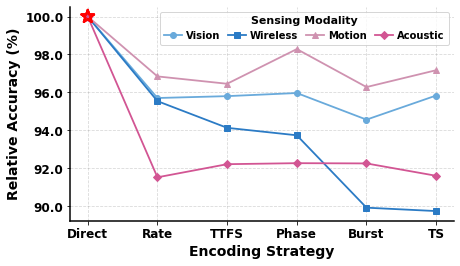

In [2]:
# Fig 2 (a) Heatmap of SNN performance across conventional sensing modalities and encoding methods

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic']
encodings = ['Direct', 'Rate', 'TTFS', 'Phase', 'Burst', 'TS']

data = np.array([
    [91.26, 87.34, 87.43, 87.58, 86.30, 87.46],  # Vision
    [83.86, 80.12, 78.94, 78.61, 75.41, 75.26],  # Wireless
    [97.90, 94.81, 94.43, 96.22, 94.26, 95.13],  # Motion
    [75.16, 68.79, 69.31, 69.35, 69.34, 68.85],  # Acoustic
])

direct = data[:, 0].reshape(-1, 1)
relative_acc = data / direct * 100  # Direct = 100%

fig, ax = plt.subplots(figsize=(6.5, 3.8))

colors = ["#69AADB", "#2b7bc5", "#CF92B0", "#D25593"]  
markers = ['o', 's', '^', 'D']

for i, modality in enumerate(modalities):
    ax.plot(encodings, relative_acc[i, :],
            marker=markers[i],
            color=colors[i],
            linewidth=1.8,
            markersize=6,
            label=modality)
    # 对 Direct 点加特殊标注
    ax.scatter(encodings[0], relative_acc[i, 0], 
               s=180, edgecolor='red', marker='*', facecolor='none', linewidth=2, zorder=5)

ax.set_ylabel('Relative Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Encoding Strategy', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(encodings)))
ax.set_xticklabels(encodings)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight('bold')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)

legend = ax.legend(title='Sensing Modality', fontsize=11, ncol=4, loc='upper right', prop={'weight': 'bold'}, 
                   handlelength=1.8, handletextpad=0.4, columnspacing=.8, )
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(11)

fig.tight_layout()
plt.savefig('./fig2a.svg', dpi=500, bbox_inches="tight")
plt.show()


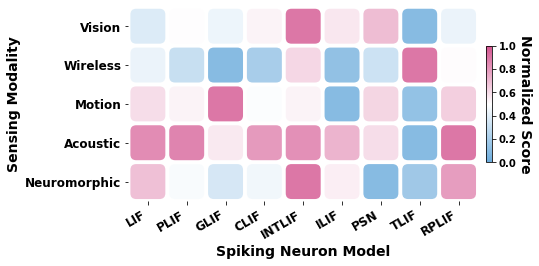

In [3]:
# Fig 2 (b) Neuron-wise performance landscape across sensing modalities

# Data
data = np.array([
    [91.36, 91.57, 91.46, 91.62, 92.27, 91.68, 91.90, 90.85, 91.44],  # Vision
    [84.19, 83.68, 82.74, 83.22, 84.96, 82.91, 83.75, 86.20, 84.51],  # Wireless
    [97.92, 97.89, 98.06, 97.87, 97.89, 97.69, 97.93, 97.71, 97.94],  # Motion
    [75.64, 75.77, 73.89, 75.38, 75.55, 74.87, 74.11, 70.93, 76.04],  # Acoustic
    [79.04, 78.29, 77.86, 78.19, 79.84, 78.54, 76.88, 77.19, 79.42],  # Neuromorphic
])

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']
neurons = ['LIF', 'PLIF', 'GLIF', 'CLIF', 'INTLIF', 'ILIF', 'PSN', 'TLIF', 'RPLIF']

# convert to DataFrame
df_long = pd.DataFrame(data, index=modalities, columns=neurons).reset_index()
df_long = df_long.melt(id_vars='index', var_name='Neuron', value_name='Score')
df_long.rename(columns={'index': 'Modality'}, inplace=True)
# normalize scores per modality
# df_long['Score'] = df_long.groupby('Modality')['Score'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# ---------------------
# 2. plot settings
# ---------------------
fig, ax = plt.subplots(figsize=(7.5, 3.8))
cell_size = 0.8
radius = 0.15

# 每行独立 cmap
cmap = mcolors.LinearSegmentedColormap.from_list("row_cmap", ["#69AADB", "white", "#D45590"]) # 

for i, modality in enumerate(modalities):
    row_data = df_long[df_long['Modality'] == modality]
    # normalize per row
    row_min, row_max = row_data['Score'].min(), row_data['Score'].max()
    norm = mcolors.TwoSlopeNorm(vmin=row_min, vcenter=(row_min + row_max) / 2, vmax=row_max)
    
    for _, row in row_data.iterrows():
        x = neurons.index(row['Neuron'])
        y = i
        color = cmap(norm(row['Score']))
        
        rect = patches.FancyBboxPatch(
            (x - cell_size / 2, y - cell_size / 2),
            cell_size, cell_size,
            boxstyle=f"round,pad=0.05, rounding_size={radius}",
            linewidth=0,
            facecolor=color,
            alpha=0.8
        )
        ax.add_patch(rect)

ax.set_xticks(range(len(neurons)))
ax.set_xticklabels(neurons, rotation=30, ha='right', va='top', fontweight='bold', fontsize=12)
ax.set_yticks(range(len(modalities)))
ax.set_yticklabels(modalities, fontweight='bold', fontsize=12)

ax.set_xlim(-0.5, len(neurons)-0.5)
ax.set_ylim(-0.5, len(modalities)-0.5)
ax.invert_yaxis()
ax.set_aspect('equal')  # 保证正方形格子

# 去掉网格和边框
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------------------
# 4. add global colorbar
# ---------------------
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.Normalize(vmin=0, vmax=1)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.02)
cbar.set_label('Normalized Score', fontsize=14, fontweight='bold', rotation=-90, labelpad=16)
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

ax.set_xlabel('Spiking Neuron Model', fontweight='bold', fontsize=14)
ax.set_ylabel('Sensing Modality', fontweight='bold', fontsize=14)


fig.tight_layout()
plt.savefig('./fig2b.svg', dpi=500, bbox_inches="tight")
plt.show()

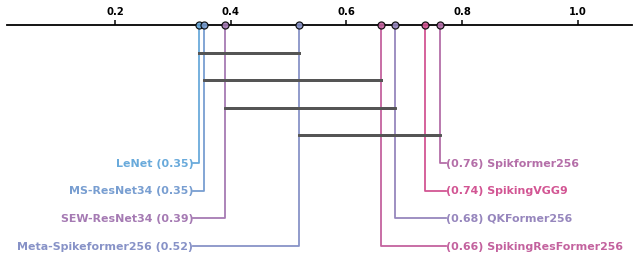

In [4]:
# Fig 2 (c) need to finish topology-res.csv CD-diagram to give architecture selection advice across all sensing modalities

fig, ax = plt.subplots(figsize=(9.5, 3.8))
data = pd.read_csv('./topology-res.csv')
avg_rank = data.groupby(
    'dataset_name').accuracy.rank(pct=True).groupby(data.classifier_name).mean()
test_results = sp.posthoc_conover_friedman(
    data, melted=True, block_col='dataset_name', group_col='classifier_name', y_col='accuracy')

cd_cmap = mcolors.LinearSegmentedColormap.from_list(
    "row_cmap",
    ["#69AADB", "#789ED1", "#8792C7", "#9686BD", "#A57AB3", "#B46EA8", "#C3629E", "#D25593"]
)
classifiers = avg_rank.index.tolist()
n = len(classifiers)
colors = [cd_cmap(i/(n-1)) for i in range(n)]
palette = {clf: col for clf, col in zip(classifiers, colors)}

sp.critical_difference_diagram(avg_rank, test_results, 
                               label_props={'fontsize': 11, 'fontweight': 'bold'}, 
                               marker_props={
                                    "s": 50,                  # marker 大小
                                    "marker": "o",             # 符号
                                    "edgecolor": "k",          # 黑色边缘
                                    "linewidths": 1.2,         # 边缘线宽
                                    "alpha": 0.9
                                },
                                crossbar_props={
                                    "linewidth": 3.0,
                                    "linestyle": "-", 
                                    "color": "#555555"
                                },
                                elbow_props={
                                    "linewidth": 1.8,
                                },
                               color_palette=palette, ax=ax)
ax.spines['top'].set_linewidth(1.8)
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
ax.tick_params(axis='both', which='major', width=1.5, length=5, labelrotation=0)

# ax.margins(x=0.35)
ax.set_xlim(ax.get_xlim()[0] - 0.3,
            ax.get_xlim()[1] + 0.3)

fig.tight_layout()
plt.savefig('./fig2c.svg', dpi=500, bbox_inches="tight")
plt.show()

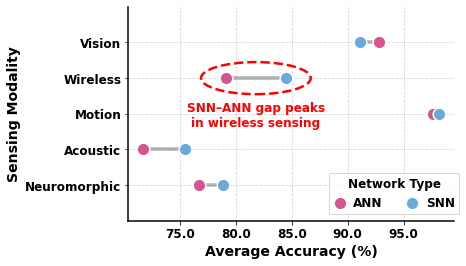

In [5]:
# Fig 2 (d) ANN vs SNN across sensing modalities (DumbBell plot)

sensings = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic'][::-1]
y = np.arange(len(sensings))

offset = 0.25
ann_mean_acc = np.array([92.53 + offset, 79.37 - offset, 97.92 - offset, 71.44 + offset, 76.39 + offset])[::-1]
snn_mean_acc = np.array([91.36 - offset, 84.19 + offset, 97.91 + offset, 75.64 - offset, 79.04 - offset])[::-1]

fig, ax = plt.subplots(figsize=(6.5, 3.8))

# difference lines
for i in range(len(y)):
    ax.plot([snn_mean_acc[i], ann_mean_acc[i]], [y[i], y[i]], color='0.7', linewidth=3.5, zorder=1)

# ANN points
ax.scatter(ann_mean_acc, y, s=160, edgecolors='white', linewidths=1.5, color='#D45590', label='ANN', zorder=3)

# SNN points
ax.scatter(snn_mean_acc, y, s=160, edgecolors='white', linewidths=1.5,color='#69AADB', label='SNN', zorder=3)

# 坐标轴设置（互换）
ax.set_yticks(y)
ax.set_yticklabels(sensings, fontsize=13)
ax.set_xlabel('Average Accuracy (%)', fontweight='bold', fontsize=14)
ax.set_ylabel('Sensing Modality', fontweight='bold', fontsize=14)

leg = fig.legend(
    title='Network Type',
    loc='lower center',
    bbox_to_anchor=(0.85, 0.18), 
    ncol=2,
    handlelength=1.,
    handletextpad=0.6,
    prop={'weight': 'bold', 'size': 12},
)
leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(12)

# spine 样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight('bold')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.set_ylim(-1, 5)

wireless_idx = sensings.index('Wireless')
y_w = y[wireless_idx]
x_center = (ann_mean_acc[wireless_idx] + snn_mean_acc[wireless_idx]) / 2
width = abs(ann_mean_acc[wireless_idx] - snn_mean_acc[wireless_idx]) + 4.5
height = 0.9
from matplotlib.patches import Ellipse
ellipse = Ellipse(
    (x_center, y_w),
    width=width,
    height=height,
    edgecolor='red',
    facecolor='none',
    linestyle='--',
    linewidth=2.5,
    zorder=2
)
ax.add_patch(ellipse)

ax.text(
    x_center,
    y_w - 0.65,
    'SNN–ANN gap peaks\nin wireless sensing',
    color='red',
    fontsize=12,
    fontweight='bold',
    ha='center',
    va='top'
)

fig.tight_layout()
plt.savefig('./fig2d.svg', dpi=500, bbox_inches="tight")
plt.show()

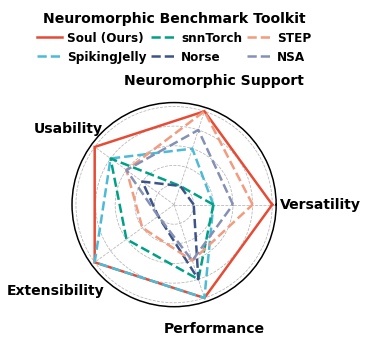

In [6]:
# fig5 (c) - radar chart of advantage comparison against other frontend benchmark toolkits

# -------------------------
# 1. Radar chart helper
# -------------------------
def radar_chart(ax, categories, values, linestyle, color, label):
    N = len(categories)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    values = values + values[:1]

    ax.plot(
        angles, values,
        linestyle,
        color=color,
        linewidth=2.5,
        label=label
    )
    # ax.fill(angles, values, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', pad=18) 

    for label in ax.get_xticklabels():
        if label.get_text() in ['Versatility', 'Extensibility']:
            label.set_y(-0.15)

    ax.set_yticklabels([])

    ax.spines['polar'].set_linewidth(1.5)
    ax.grid(linestyle='--', alpha=0.9)


# -------------------------
# 2. Example data (5-dim)
# -------------------------

fig, ax = plt.subplots(
    1, 1,
    figsize=(5.5, 5.5),
    subplot_kw=dict(polar=True)
)

# application support, model support, documentation, add new model, ...
categories = ['Versatility', 'Neuromorphic Support', 'Usability', 'Extensibility', 'Performance']
method_soul = [5, 5, 5, 5, 5]
method_sj = [2, 3, 4, 5, 5]
method_snntorch = [2, 1, 4, 3, 4]
method_norse = [1, 1, 2, 1, 4]
method_step = [4, 5, 3, 2, 3]
method_nsa = [3, 4, 3, 1, 3]

radar_chart(ax, categories, method_soul, '-', '#E64B35', 'Soul (Ours)')
radar_chart(ax, categories, method_sj, '--', '#4DBBD5', 'SpikingJelly')
radar_chart(ax, categories, method_snntorch, '--', '#00A087', 'snnTorch')
radar_chart(ax, categories, method_norse, '--', '#3C5488', 'Norse')
radar_chart(ax, categories, method_step, '--', '#F39B7F', 'STEP')
radar_chart(ax, categories, method_nsa, '--', '#8491B4', 'NSA') # neuromorphic sequential arena


legend = ax.legend(
    title='Neuromorphic Benchmark Toolkit',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.5),
    ncol=3,
    frameon=False,
    handlelength=2.1, 
    handletextpad=0.4, 
    columnspacing=.4, 
    prop={'weight': 'bold', 'size':12},
)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(14)

fig.tight_layout()
plt.savefig('./fig5c.svg', dpi=500, bbox_inches="tight")
plt.show()


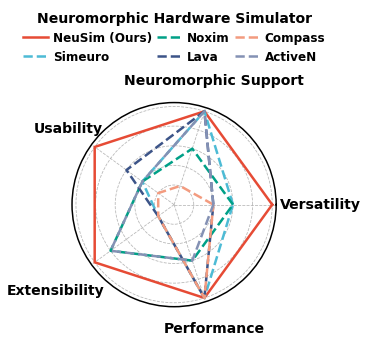

In [7]:
# fig5 (d) - radar chart of advantage comparison against other backend chip simulator toolkits

# -------------------------
# 1. Radar chart helper
# -------------------------
def radar_chart(ax, categories, values, linestyle, color, label):
    N = len(categories)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    values = values + values[:1]

    ax.plot(
        angles, values,
        linestyle,
        color=color,
        linewidth=2.5,
        label=label
    )
    # ax.fill(angles, values, color=color, alpha=0.01)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', pad=18) 

    for label in ax.get_xticklabels():
        if label.get_text() in ['Versatility', 'Extensibility']:
            label.set_y(-0.15)

    ax.set_yticklabels([])

    ax.spines['polar'].set_linewidth(1.5)
    ax.grid(linestyle='--', alpha=0.9)


# -------------------------
# 2. Example data (5-dim)
# -------------------------

fig, ax = plt.subplots(
    1, 1,
    figsize=(5.5, 5.5),
    subplot_kw=dict(polar=True)
)

categories = ['Versatility', 'Neuromorphic Support', 'Usability', 'Extensibility', 'Performance']
method_neusim = [5, 5, 5, 5, 5]
method_simeuro = [3, 5, 2, 1, 5]
method_lava = [2, 5, 3, 1, 5]
method_noxim = [3, 3, 2, 4, 3]
method_compass = [2, 1, 1, 1, 5]
method_activen = [2, 5,2 ,4 ,3]

radar_chart(ax, categories, method_neusim, '-', '#E64B35', 'NeuSim (Ours)')
radar_chart(ax, categories, method_simeuro, '--', '#4DBBD5', 'Simeuro')
radar_chart(ax, categories, method_noxim, '--', '#00A087', 'Noxim')
radar_chart(ax, categories, method_lava, '--', '#3C5488', 'Lava')
radar_chart(ax, categories, method_compass, '--', '#F39B7F', 'Compass')
radar_chart(ax, categories, method_activen, '--', '#8491B4', 'ActiveN')

legend = ax.legend(
    title='Neuromorphic Hardware Simulator',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.5),
    ncol=3,
    frameon=False,
    handlelength=2.1, 
    handletextpad=0.4, 
    columnspacing=.4, 
    prop={'weight': 'bold', 'size':12},
)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(14)

fig.tight_layout()
plt.savefig('./fig5d.svg', dpi=500, bbox_inches="tight")
plt.show()


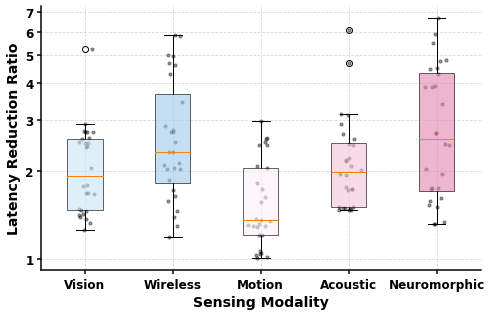

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullLocator

modalities = ["Vision", "Wireless", "Motion", "Acoustic", "Neuromorphic"]

data = [
    [2.426, 2.746, 2.727, 2.435, 2.727, 2.724, 2.505, 5.245, 2.906, 1.414, 1.666, 2.046, 2.574, 2.489, 2.598, 2.525, 1.684, 1.683, 1.791, 1.786, 1.368, 1.425, 1.488, 1.464, 1.397, 1.325, 1.259, 1.472],
    [2.107, 2.132, 4.685, 2.525, 5.816, 5.001, 2.866, 2.328, 3.452, 4.633, 2.759, 2.720, 4.950, 5.863, 4.316, 2.322, 1.860, 1.293, 1.647, 2.052, 2.028, 1.391, 1.719, 2.027, 1.586, 1.188, 1.461, 2.731],
    [1.374, 1.289, 1.322, 1.628, 1.732, 1.350, 2.594, 1.825, 2.048, 2.973, 1.051, 1.006, 2.458, 2.579, 2.517, 2.463, 1.571, 1.302, 1.310, 2.082, 1.016, 1.065, 1.036, 1.040, 1.208, 1.294, 1.211, 1.366],
    [2.174, 2.224, 2.182, 2.085, 6.073, 2.022, 1.938, 1.955, 2.569, 2.677, 2.450, 2.470, 3.124, 4.694, 2.910, 3.132, 1.474, 1.473, 1.481, 1.477, 1.502, 1.495, 1.507, 1.498, 1.726, 1.765, 1.740, 1.732],
    [5.914, 5.486, 3.893, 3.924, 2.705, 2.460, 3.895, 4.297, 3.405, 6.670, 4.515, 4.493, 2.479, 2.693, 4.781, 4.789, 1.749, 1.619, 1.320, 1.316, 1.342, 1.576, 1.506, 1.529, 2.031, 1.959, 1.739, 1.756]
]

fig, ax = plt.subplots(figsize=(7, 4.5))

bp = ax.boxplot(data,
                patch_artist=True,
                labels=modalities,
                showfliers=True,
                widths=0.4)

colors = ["#CAE5F8", "#9DCBED", "#FAEFF5", "#F2C5DA", "#E286AF"]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, vals in enumerate(data):
    x = np.random.normal(i+1, 0.06, size=len(vals))
    ax.scatter(x, vals, color='black', s=10, alpha=0.4)

ax.set_yscale("log")

ax.set_yticks([1, 2, 3, 4, 5, 6, 7])
ax.set_yticklabels(['1', '2', '3', '4', '5', '6', '7'])
ax.yaxis.set_minor_locator(NullLocator()) 

ax.set_xlabel("Sensing Modality", fontsize=14, fontweight='bold')
ax.set_ylabel("Latency Reduction Ratio", fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.3, zorder=0)

ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=4)

fig.canvas.draw()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('./fig4a.svg', dpi=500, bbox_inches="tight")
plt.show()

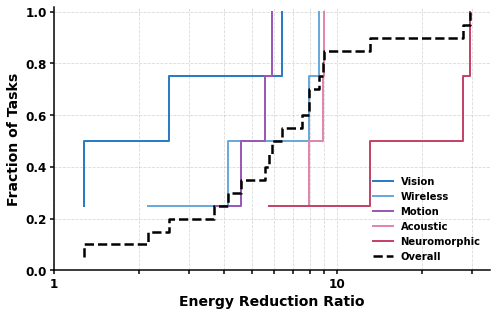

In [ ]:
from matplotlib.ticker import FuncFormatter

# fig4 (b) ann vs snn energy difference
# 讨论同结构的ann snn在实际设备执行时理论推理能耗差异
energy_ann = {
    "Vision":        np.array([67.49, 67.49, 55.95, 55.95]),
    "Wireless":      np.array([3919.48, 11790.94, 1698.64, 1388.92]),
    "Motion":        np.array([219.52, 292.69, 292.69, 73.19]),
    "Acoustic":     np.array([2891.85, 2891.97, 2891.85, 2892.04]),
    "Neuromorphic":  np.array([230.93, 528.68, 2891.9, 2891.97])
}

energy_snn = {
    "Vision":        np.array([52.9, 52.94, 21.93, 8.74]),
    "Wireless":      np.array([452, 2853.14, 791.23, 174.85]),
    "Motion":        np.array([39.48, 49.76, 64.14, 19.98]),
    "Acoustic":     np.array([322.84, 321.21, 383.19, 363.67]),
    "Neuromorphic":  np.array([40.14, 40.39, 97.76, 104.04])
}

energy_data = {key : val / energy_snn[key] for key, val in energy_ann.items()}

colors = {
    "Vision": "#2B7BC5",   
    "Wireless": "#69AADB",   
    "Motion": "#9B59B6",    
    "Acoustic": "#E286AF", 
    "Neuromorphic": "#C44569"
}

fig, ax = plt.subplots(figsize=(7, 4.5))

for modality, values in energy_data.items():
    sorted_vals = np.sort(values)
    y = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax.step(sorted_vals, y, where="post",
            label=modality,
            color=colors[modality],
            linewidth=2)

all_values = np.concatenate(list(energy_data.values()))
sorted_all = np.sort(all_values)
y_all = np.arange(1, len(sorted_all)+1) / len(sorted_all)

ax.step(sorted_all, y_all, where="post",
        color="black", linewidth=2.5, linestyle="--",
        label="Overall")

ax.set_xscale("log")

def custom_formatter(x, pos):
    if x == int(x):
        return f'{int(x)}'
    else:
        return f'{x:g}'

ax.xaxis.set_major_formatter(FuncFormatter(custom_formatter))

ax.set_xlabel("Energy Reduction Ratio", fontsize=14, fontweight='bold')
ax.set_ylabel("Fraction of Tasks", fontsize=14, fontweight='bold')

ax.set_xlim(left=1)  
ax.set_ylim(0, 1.02)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)

ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=4)
ax.tick_params(axis='x', which='minor', width=1.5, length=4)

legend = ax.legend(frameon=False, fontsize=11, loc='lower right',
                   prop={'weight': 'bold'})

fig.canvas.draw()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('./fig4b.svg', dpi=500, bbox_inches="tight")
plt.show()

Memory Footprint Analysis: ANN vs SNN
Modality          ANN Mean   SNN Mean   Increase      p-value
------------------------------------------------------------
Vision              224.16     239.40       6.8%     0.000111
Wireless            579.50     822.37      41.9%     0.127170
Motion              309.44     326.58       5.5%     0.009026
Acoustic            465.39     615.91      32.3%     0.001405
Neuromorphic        355.67     588.85      65.6%     0.096342


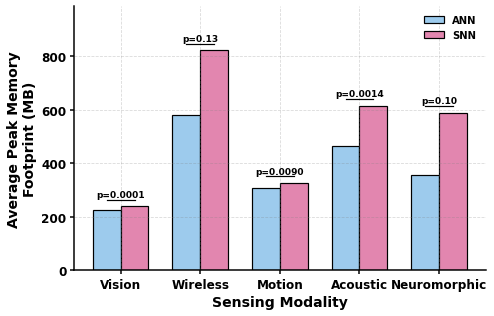

In [10]:
from scipy import stats

ann_memory_raw = {
    "Vision":        np.array([223.86, 224.38, 224.24, 224.16]),
    "Wireless":      np.array([542.88, 1174.66, 276.08, 324.39]),
    "Motion":        np.array([309.73, 337.81, 338.12, 252.11]),
    "Acoustic":      np.array([464.24, 466.2, 465.18, 465.93]),
    "Neuromorphic":  np.array([234.7, 255.98, 465.95, 466.04])
}

snn_memory_raw = {
    "Vision":        np.array([237.94, 241.11, 239.0, 239.57]),
    "Wireless":      np.array([720.6, 1759.98, 405.82, 403.08]),
    "Motion":        np.array([326.43, 356.82, 361.31, 261.78]),
    "Acoustic":      np.array([640.93, 594.13, 593.33, 635.27]),
    "Neuromorphic":  np.array([286.11, 337.35, 833.8, 898.14])
}

modalities = ["Vision", "Wireless", "Motion", "Acoustic", "Neuromorphic"]

ann_memory = np.array([ann_memory_raw[m].mean() for m in modalities])
snn_memory = np.array([snn_memory_raw[m].mean() for m in modalities])

p_values = []
for m in modalities:
    t_stat, p_val = stats.ttest_rel(ann_memory_raw[m], snn_memory_raw[m])
    p_values.append(p_val)

print("=" * 60)
print("Memory Footprint Analysis: ANN vs SNN")
print("=" * 60)
print(f"{'Modality':<15} {'ANN Mean':>10} {'SNN Mean':>10} {'Increase':>10} {'p-value':>12}")
print("-" * 60)
for m, ann, snn, p in zip(modalities, ann_memory, snn_memory, p_values):
    increase = (snn - ann) / ann * 100
    print(f"{m:<15} {ann:>10.2f} {snn:>10.2f} {increase:>9.1f}% {p:>12.6f}")
print("=" * 60)

colors = {"ANN": "#9DCBED", "SNN": "#E286AF"}

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))

x = np.arange(len(modalities))
width = 0.35

rects1 = ax.bar(x - width/2, ann_memory, width, edgecolor='black', linewidth=1.2,
                label='ANN', color=colors["ANN"])
rects2 = ax.bar(x + width/2, snn_memory, width, edgecolor='black', linewidth=1.2,
                label='SNN', color=colors["SNN"])

ax.set_xlabel("Sensing Modality", fontsize=14, fontweight='bold')
ax.set_ylabel("Average Peak Memory\nFootprint (MB)", fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(modalities)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.3, zorder=0)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=4)

legend = ax.legend(frameon=False, fontsize=11, loc='upper right',
                   prop={'weight': 'bold'})

def add_significance_with_pvalue(ax, x_pos, ann_val, snn_val, p_val, width):
    """在两个柱子上方添加横线和 p 值"""
    x1 = x_pos - width/2
    x2 = x_pos + width/2

    line_y = max(ann_val, snn_val) + 25

    ax.plot([x1, x2], [line_y, line_y], color='black', linewidth=1.2)

    if p_val < 0.0001:
        p_text = f'p={p_val:.1e}'
    elif p_val < 0.01:
        p_text = f'p={p_val:.4f}'
    else:
        p_text = f'p={p_val:.2f}'

    ax.text((x1 + x2) / 2, line_y + 2, p_text,
            ha='center', va='bottom', fontsize=9, fontweight='bold')

for i, (m, p_val) in enumerate(zip(modalities, p_values)):
    add_significance_with_pvalue(ax, i, ann_memory[i], snn_memory[i], p_val, width)

ax.set_ylim(0, max(snn_memory) * 1.2)

fig.canvas.draw()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('./fig4c.svg', dpi=500, bbox_inches="tight")
plt.show()

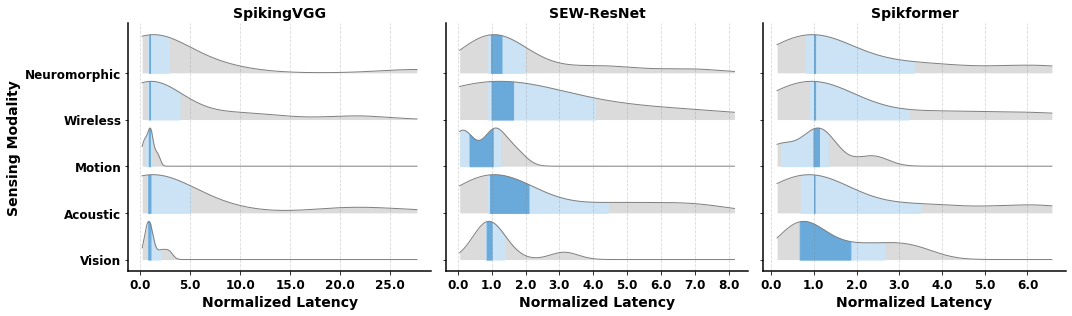

In [ ]:
# fig4 (d) vgg9, resnet34, former256 in 5 sensing 7 devices latency comparison
# for each modality and each dataset, normlize latency: latency / median_latency_across_devices 
from scipy.stats import gaussian_kde
from matplotlib.ticker import FormatStrFormatter

modalities = ['Vision', 'Acoustic', 'Motion', 'Wireless', 'Neuromorphic']
devices = ['Raspberry Pi 4B', 'Jetson Orin Nano', 'Jetson Orin NX',
           'Jetson AGX Orin', 'Redmi K80', 'Google Pixel 6', 'Huawei Mate 40 Pro']
n_modalities = len(modalities)
n_devices = len(devices)

# vgg9
data_vgg = {
    'Vision': np.array([
        [58.199503, 43.327921, 53.893657, 154.298406, 41.27859, 43.080599, 113.424077], 
        [58.192786, 42.937266, 53.90641, 154.981295, 39.400052, 41.149115, 113.1947],
        [58.094945, 42.635199, 53.474302, 153.792755, 37.893918, 40.003532, 111.565517],
        [58.283231, 42.6427, 53.673459, 154.380247, 37.854639, 40.150687, 113.377395]
    ]),
    'Acoustic': np.array([
        [118.285656, 72.280903, 147.082652, 3277.350254, 76.596663, 180.47715, 915.170213],
        [118.760388, 74.781692, 246.617837, 3278.635555, 79.953607, 159.03702, 754.252277],
        [118.367136, 75.494808, 156.902047, 3264.611266, 80.1195, 160.041442, 941.085396],
        [115.776031, 76.425913, 79.123353, 3278.424801, 80.090735, 178.756999, 887.713643],
    ]),
    'Motion': np.array([
        [33.080061, 19.606114, 28.618001, 33.658824, 29.802077, 7.465748, 9.29026],
        [33.741489, 19.848547, 28.864712, 53.317764, 30.099483, 11.960862, 15.23721],
        [33.772238, 19.595933, 28.861605, 53.681553, 30.127734, 12.354346, 15.377737],
        [32.662377, 19.06523, 28.381483, 17.546625, 30.406322, 3.214494, 3.685503],
    ]),
    'Wireless': np.array([
        [197.62629, 125.87825, 147.082652, 4288.04765, 122.288112, 249.505122, 1530.339987],
        [303.858959, 232.372828, 246.617837, 6540.681294, 207.8644, 568.735726, 3038.3305],
        [199.184374, 134.369862, 156.902047, 2300.404068, 139.455276, 172.032132, 894.398694],
        [110.954928, 54.204362, 79.123353, 1212.784692, 79.398746, 111.465608, 397.379837],
    ]),
    'Neuromorphic': np.array([
        [60.328321, 45.119871, 54.986292, 276.036655, 43.411078, 59.375983, 160.291545],
        [63.058584, 47.481531, 57.206429, 523.520924, 47.621017, 66.842078, 213.288389],
        [118.985584, 75.83229, 87.252427, 3265.516808, 80.506266, 171.403699, 917.90768],
        [118.131001, 76.711695, 87.175467, 3284.136409, 80.277889, 175.425246, 906.579038],
    ]),
}

# sew-resnet34
data_resnet = {
    'Vision': np.array([
        [66.08953, 64.900213, 80.590168, 49.922338, 79.848143, 111.777641, 250.666591],
        [66.13574, 64.714119, 80.592333, 49.852746, 79.810381, 110.783562, 250.340157],
        [66.175155, 64.491117, 80.310266, 48.212066, 79.272672, 111.24412, 249.548749],
        [66.496838, 64.441943, 80.350043, 48.752089, 78.849318, 109.148362, 247.176381],
    ]),
    'Acoustic': np.array([
        [82.975914, 72.758526, 88.756013, 649.377554, 94.039607, 202.800245, 431.088064],
        [83.017948, 73.148915, 88.819312, 650.391256, 94.654415, 200.394553, 415.832078],
        [82.686266, 75.329277, 88.84701, 645.554371, 94.118681, 202.483533, 448.75442],
        [71.114236, 74.514812, 88.966624, 643.064628, 94.584569, 197.528769, 447.256079],
    ]),
    'Motion': np.array([
        [34.412291, 33.50309, 41.679195, 10.957567, 56.82285, 1.880711, 2.12657],
        [34.452391, 32.942148, 41.812848, 11.102431, 57.203424, 1.837833, 2.188867],
        [34.653136, 32.997301, 41.783097, 10.07888, 57.306413, 1.93997, 2.201088],
        [34.247829, 32.485861, 41.582235, 9.642539, 56.573026, 1.623527, 1.716516],
    ]),
    'Wireless': np.array([
        [90.308898, 78.683011, 92.787872, 944.24038, 105.232379, 213.897545, 701.298573, ], 
        [131.124117, 144.561664, 130.221334, 2831.772908, 144.082637, 312.766283, 945.143773], 
        [85.818311, 79.968375, 92.391259, 717.339016, 110.18576, 178.348084, 427.889345], 
        [77.271575, 65.235855, 85.280824, 452.013239, 88.051906, 148.104822, 406.660925]
    ]),
    'Neuromorphic': np.array([
        [67.187752, 67.137181, 81.506089, 105.836591, 83.20663, 117.218937, 315.190876],
        [69.220658, 67.229297, 82.6781, 159.646052, 85.023163, 122.962311, 325.9521],
        [82.937938, 74.825222, 88.829678, 646.798612, 94.436666, 188.399657, 445.433002],
        [83.16376, 73.828041, 88.779477, 648.130804, 94.669207, 192.236191, 444.933383]
    ]),
}

# spikformer
data_former = {
    'Vision': np.array([
        [28.971765, 29.165281, 27.819493, 148.560925, 44.110836, 83.287212, 117.118125],
        [29.067026, 29.051371, 27.648876, 149.344652, 44.233032, 82.271153, 117.6906],
        [28.740287, 28.258914, 27.222143, 148.379688, 43.929757, 81.743684, 117.686835],
        [28.895708, 27.871102, 27.055102, 149.274126, 43.936492, 81.782985, 117.961259],
    ]),
    'Acoustic': np.array([
        [335.999109, 496.548374, 478.471684, 3007.198133, 334.07841, 511.943126, 1779.810262],
        [336.22267, 498.240851, 493.580048, 3038.831649, 333.837267, 509.45269, 1769.633501],
        [338.403885, 495.079542, 491.118602, 3042.13508, 332.124217, 515.795796, 1719.179209],
        [342.674814, 492.950733, 490.133073, 3052.420927, 332.669943, 511.902686, 1788.376836],
    ]),
    'Motion': np.array([
        [14.927842, 20.41265, 19.553633, 14.310522, 34.907918, 2.065935, 3.285687],
        [14.924918, 16.710227, 19.731548, 14.36668, 34.966538, 2.098312, 3.40131],
        [14.568656, 16.805595, 19.728768, 14.310125, 35.073283, 2.153602, 3.357775],
        [14.409518, 17.325227, 19.52776, 14.005327, 34.809162, 2.068331, 3.268517],
    ]),
    'Wireless': np.array([
        [543.947255, 679.518626, 659.247014, 4288.687055, 495.365131, 794.031476, 2692.830926],
        [2324.270128, 2542.723368, 2555.484116, 14219.16183, 1288.601348, 2746.032297, 7770.606483],
        [331.784041, 494.556942, 490.50682, 2933.970762, 322.398853, 506.465535, 1865.523944],
        [188.731269, 215.192843, 228.517487, 1691.117218, 206.170614, 301.562981, 976.236889],
    ]),
    'Neuromorphic': np.array([
        [46.989154, 52.022074, 48.382977, 353.783353, 63.8144, 126.352823, 208.790578],
        [73.339439, 100.586581, 102.021223, 687.330589, 94.893333, 195.112445, 382.524343],
        [339.015232, 501.250836, 493.165696, 3095.102182, 336.125292, 534.045757, 1791.042494],
        [337.821468, 498.111248, 495.301633, 3067.644716, 334.678322, 516.844017, 1789.048067],
    ]),
}

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

def draw_kde(axs, data, index):
    for mod in modalities:
        lat_norm = data[mod] / np.median(data[mod], axis=1, keepdims=True)
        data[mod] = lat_norm.flatten()

    ridge_data = [v for v in data.values()]

    offset = 1.1
    x_all = np.concatenate(ridge_data)
    x_min, x_max = np.percentile(x_all, [1, 99])
    x = np.linspace(x_min, x_max, 500)

    for i, values in enumerate(ridge_data):
        kde = gaussian_kde(values)
        y = kde(x)
        y = y / y.max() * 0.9

        base = i * offset

        axs[index].plot(x, y + base, color='gray', linewidth=1)
        axs[index].fill_between(x, base, y + base, color='lightgray', alpha=0.8, linewidth=0)

        q1, q2, q3 = np.percentile(values, [25, 50, 75])
        q_low, q_high = np.percentile(values, [40, 60])

        axs[index].fill_between(x, base, y + base,
                        where=(x >= q1) & (x <= q3),
                        color='#CAE5F8', alpha=0.9)  

        axs[index].fill_between(x, base, y + base,
                        where=(x >= q_low) & (x <= q_high),
                        color='#69AADB', alpha=1.0) 

    axs[index].set_yticks(np.arange(len(modalities)) * offset)
    if index == 0:
        axs[index].set_yticklabels(modalities)
        axs[index].set_ylabel('Sensing Modality', fontweight='bold', fontsize=14)
    else:
        axs[index].set_yticklabels([])
    axs[index].set_xlabel('Normalized Latency', fontweight='bold', fontsize=14)
    axs[index].xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    axs[index].spines['top'].set_visible(False)
    axs[index].spines['right'].set_visible(False)
    for spine in axs[index].spines.values():
        spine.set_linewidth(1.5)
    for label in axs[index].get_xticklabels() + axs[index].get_yticklabels(): 
        label.set_fontsize(12) 
        label.set_fontweight('bold')
    axs[index].grid(True, axis='x', linestyle='--', color='gray', alpha=0.3)

draw_kde(axs, data_vgg, 0)
draw_kde(axs, data_resnet, 1)
draw_kde(axs, data_former, 2)

axs[0].set_title('SpikingVGG', fontweight='bold', fontsize=14)
axs[1].set_title('SEW-ResNet', fontweight='bold', fontsize=14)
axs[2].set_title('Spikformer', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('./fig4d.svg', dpi=500, bbox_inches="tight")
plt.show()

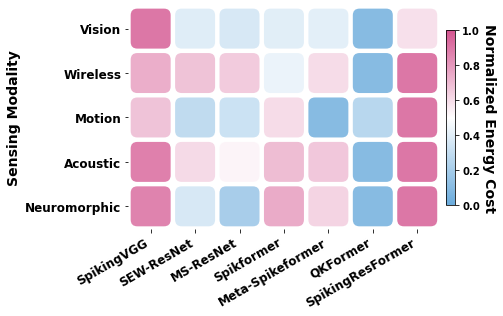

In [12]:
# fig4 (e) average peak memory footprint (all types of SNNs across five sensing modalities) on seven representative edge devices. Values are log-transformed to improve visual comparability across devices with different memory hierarchies.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
cell_size = 0.8
radius = 0.15

# Data
data = np.array([
    [1236.96, 128.17, 113.09, 132.28, 138.1, 34.10, 307.78],  # Vision
    [5134.435, 4278.78, 3959.485, 1999.245, 3396.105, 703.9075, 8612.12],  # Wireless
    [42.805, 11.22, 12.855, 33.3875, 5.745, 10.2375, 95.2825],  # Motion
    [3022.835, 1474.27, 1196.29, 1865.07, 1714.4975, 369.125, 3288.355],  # Acoustic
    [3486.78, 800.9125, 499.4825, 2440.7275, 1702.335, 357.2175, 3889.555],  # Neuromorphic
])

data = np.log10(data + 1e-8)
row_min = data.min(axis=1, keepdims=True)
row_max = data.max(axis=1, keepdims=True)

data = (data - row_min) / (row_max - row_min)

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']
devices = [
    'SpikingVGG', 'SEW-ResNet', 'MS-ResNet', 'Spikformer',
    'Meta-Spikeformer', 'QKFormer', 'SpikingResFormer'
]

# convert to DataFrame
df_long = pd.DataFrame(data, index=modalities, columns=devices).reset_index()
df_long = df_long.melt(id_vars='index', var_name='Neuron', value_name='Score')
df_long.rename(columns={'index': 'Modality'}, inplace=True)
# normalize scores per modality
# df_long['Score'] = df_long.groupby('Modality')['Score'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

# 每行独立 cmap
cmap = mcolors.LinearSegmentedColormap.from_list("row_cmap", ["#69AADB", "white", "#D45590"]) #

for i, modality in enumerate(modalities):
    row_data = df_long[df_long['Modality'] == modality]
    # normalize per row
    row_min, row_max = row_data['Score'].min(), row_data['Score'].max()
    norm = mcolors.TwoSlopeNorm(vmin=row_min, vcenter=(row_min + row_max) / 2, vmax=row_max)

    for _, row in row_data.iterrows():
        x = devices.index(row['Neuron'])
        y = i
        color = cmap(norm(row['Score']))

        rect = patches.FancyBboxPatch(
            (x - cell_size / 2, y - cell_size / 2),
            cell_size, cell_size,
            boxstyle=f"round,pad=0.05, rounding_size={radius}",
            linewidth=0,
            facecolor=color,
            alpha=0.8
        )
        ax.add_patch(rect)

ax.set_xticks(range(len(devices)))
ax.set_xticklabels(devices, rotation=30, ha='right', va='top', fontweight='bold', fontsize=12)
ax.set_yticks(range(len(modalities)))
ax.set_yticklabels(modalities, fontweight='bold', fontsize=12)

ax.set_xlim(-0.5, len(devices)-0.5)
ax.set_ylim(-0.5, len(modalities)-0.5)
ax.invert_yaxis()
ax.set_aspect('equal')  # 保证正方形格子

# 去掉网格和边框
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)


sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.Normalize(vmin=0, vmax=1)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Normalized Energy Cost', fontsize=14, fontweight='bold', rotation=-90, labelpad=16)
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

# ax.set_xlabel('Architecture', fontweight='bold', fontsize=14)
ax.set_ylabel('Sensing Modality', fontweight='bold', fontsize=14)
# ax.set_title('Theoretical Energy Cost', fontweight='bold', fontsize=14)

plt.tight_layout()
fig.savefig('./fig4e.svg',
            format='svg', bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

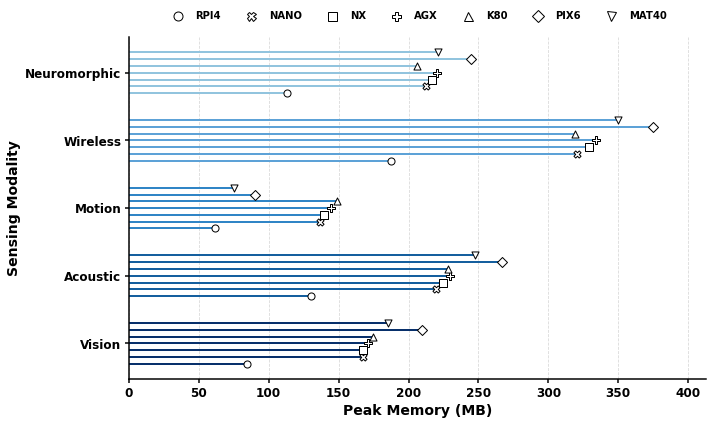

In [13]:
from matplotlib.lines import Line2D

data = np.array([
    [86577.875, 171772.6875, 171219, 174853.625, 178460.1875, 214311.75, 189433.25],
    [192215.3125, 328046.7143, 337303.375, 342321.75, 326502.125, 383983.5625, 358266.75],
    [63341.6875, 139955.875, 142540.5625, 148091.3125, 152197.25, 92341.375, 77135.25],
    [133534.4375, 224970.1875, 230239.375, 234878.1875, 234048, 272909.6855, 253166.875],
    [115767.625, 217727.875, 221783.5, 225742.0625, 211269.75, 250903.6875, 226470.875],
])

# 将 KB 转换为 MB
data = data / 1024

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']
devices = ['RPI4', 'NANO', 'NX', 'AGX', 'K80', 'PIX6', 'MAT40']

df = pd.DataFrame(data, index=modalities, columns=devices)

new_order = ['Vision', 'Acoustic', 'Motion', 'Wireless', 'Neuromorphic']
df = df.reindex(new_order)

fig, ax = plt.subplots(figsize=(10, 6))

modality_colors = ["#08306B", "#155F9E", "#3085C6", "#5DA2D7", "#92C4DE"]

device_markers = ['o', 'X', 's', 'P', '^', 'D', 'v']

y_positions = np.arange(len(new_order))
bar_height = 0.10

for j, device in enumerate(devices):
    values = df[device].values
    y_offset = (j - 3) * bar_height

    for i, (modality, val) in enumerate(zip(new_order, values)):
        y = i + y_offset

        ax.hlines(y, xmin=0, xmax=val, color=modality_colors[i], linewidth=2, zorder=2)

        ax.scatter(val, y, s=50, color='white', edgecolor='black',
                   linewidth=1.0, marker=device_markers[j], zorder=3)

device_legend = [Line2D([0], [0], color='white', marker=device_markers[j],
                        markersize=9, markerfacecolor='white', markeredgecolor='black',
                        markeredgewidth=1.0, linewidth=0, label=devices[j])
                 for j in range(len(devices))]

ax.legend(handles=device_legend, loc='lower center', frameon=False,
          fontsize=10, prop={'weight': 'bold'}, ncol=7,
          bbox_to_anchor=(0.5, 1.02))

ax.set_yticks(y_positions)
ax.set_yticklabels(new_order)
ax.set_xlabel('Peak Memory (MB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sensing Modality', fontsize=14, fontweight='bold')

ax.set_xlim(0, df.values.max() * 1.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)

ax.grid(axis='x', linestyle='--', color='gray', alpha=0.3, zorder=0)

ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=4)

fig.canvas.draw()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('./fig4f.svg', format='svg', dpi=500, bbox_inches='tight')
plt.show()

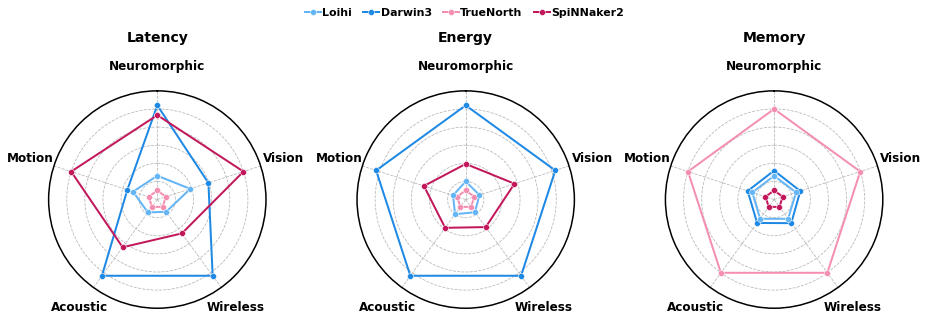

In [14]:
from matplotlib.lines import Line2D

data_latency = [
        [682.0, 59.65, 1368.59, 836.90, 42.39],
        [171.14, 40.24, 147.99, 144.94, 38.16], 
        [2000, 300, 4000, 1500, 200],
        [183.79, 21.71, 348.77, 223.02, 10.33],
]
data_energy = [
        [94.96, 5.78, 331.64, 128.09, 2.52],
        [14.56, 1.28, 37.99, 19.19, 0.57], 
        [313.66, 7.70, 1048.45, 441.38, 3.11],
        [40.77, 2.14, 114.54, 55.27, 1.07],
]
data_memory = [
        [38168, 4784, 116376, 62608, 2236],
        [35520, 4608, 107712, 58368, 2112], 
        [9320.25, 1134.75, 28531.31, 15312.75, 525.94],
        [118833.18, 14468.06, 363774.23, 195237.56, 6705.70],
]

def normalize_to_efficiency(data, offset_idx=None, offset_val=0.06):
    """转换为效率指标：取倒数，越大越好"""
    data = np.array(data)
    efficiency = 1.0 / data
    col_min = efficiency.min(axis=0, keepdims=True)
    col_max = efficiency.max(axis=0, keepdims=True)
    normalized = (efficiency - col_min) / (col_max - col_min + 1e-8)
    normalized = normalized * 0.9 + 0.1
    if offset_idx is not None:
        normalized[offset_idx] = normalized[offset_idx] + offset_val
    return normalized.tolist()

data_latency = normalize_to_efficiency(data_latency, offset_idx=1, offset_val=0.04) 
data_energy = normalize_to_efficiency(data_energy, offset_idx=1, offset_val=0.04) 
data_memory = normalize_to_efficiency(data_memory, offset_idx=1, offset_val=0.04) 

def draw_radar(ax, data, show_label=True):
    categories = ['Neuromorphic', 'Vision', 'Wireless', 'Acoustic', 'Motion']
    N = len(categories)

    method_a = data[0] + [data[0][0]]
    method_b = data[1] + [data[1][0]]
    method_c = data[2] + [data[2][0]]
    method_d = data[3] + [data[3][0]]

    colors = ["#64B5F6", "#1E88E5", "#F48FB1", "#C2185B"]
    color_a = colors[0]   # Loihi
    color_b = colors[1]   # Darwin3
    color_c = colors[2]   # TrueNorth
    color_d = colors[3]   # SpiNNaker2
    
    fill_alpha = 0.0
    line_width = 2.0
    marker_size = 6

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1] 

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angles, method_b, 'o-', color=color_b, linewidth=line_width,
            markersize=marker_size, markeredgecolor='white', markeredgewidth=0.5,
            label='Darwin3' if show_label else None, zorder=3)
    ax.fill(angles, method_b, alpha=fill_alpha, color=color_b)

    ax.plot(angles, method_a, 'o-', color=color_a, linewidth=line_width,
            markersize=marker_size, markeredgecolor='white', markeredgewidth=0.5,
            label='Loihi' if show_label else None, zorder=4)
    ax.fill(angles, method_a, alpha=fill_alpha, color=color_a)

    ax.plot(angles, method_c, 'o-', color=color_c, linewidth=line_width,
            markersize=marker_size, markeredgecolor='white', markeredgewidth=0.5,
            label='TrueNorth' if show_label else None, zorder=3)
    ax.fill(angles, method_c, alpha=fill_alpha, color=color_c)

    ax.plot(angles, method_d, 'o-', color=color_d, linewidth=line_width,
            markersize=marker_size, markeredgecolor='white', markeredgewidth=0.5,
            label='SpiNNaker2' if show_label else None, zorder=3)
    ax.fill(angles, method_d, alpha=fill_alpha, color=color_d)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', pad=14) 

    ax.set_ylim(0, 1.2)
    ax.set_yticklabels([], fontsize=6.5)
    ax.grid(linestyle='--', alpha=0.9)
    ax.spines['polar'].set_linewidth(1.5)

fig, axs = plt.subplots(
    1, 3,
    figsize=(13, 5),
    subplot_kw=dict(polar=True)
)

draw_radar(axs[0], data_latency, show_label=True)
draw_radar(axs[1], data_energy, show_label=False)
draw_radar(axs[2], data_memory, show_label=False)

axs[0].set_title('Latency', fontweight='bold', fontsize=14, pad=18)
axs[1].set_title('Energy', fontweight='bold', fontsize=14, pad=18)
axs[2].set_title('Memory', fontweight='bold', fontsize=14, pad=18)

colors = ["#64B5F6", "#1E88E5", "#F48FB1", "#C2185B"]
legend_elements = [
    Line2D([0], [0], color=colors[0], marker='o', markersize=6, 
           markeredgecolor='white', markeredgewidth=0.5, linewidth=2, label='Loihi'),
    Line2D([0], [0], color=colors[1], marker='o', markersize=6, 
           markeredgecolor='white', markeredgewidth=0.5, linewidth=2, label='Darwin3'),
    Line2D([0], [0], color=colors[2], marker='o', markersize=6, 
           markeredgecolor='white', markeredgewidth=0.5, linewidth=2, label='TrueNorth'),
    Line2D([0], [0], color=colors[3], marker='o', markersize=6, 
           markeredgecolor='white', markeredgewidth=0.5, linewidth=2, label='SpiNNaker2'),
]

legend = fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.985),  
    ncol=4,
    handlelength=1.5,
    handletextpad=0.1,
    columnspacing=1.0,
    borderpad=0.1,
    labelspacing=0.15,
    prop={'weight': 'bold', 'size':11},
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.955])  
plt.savefig('./fig4g.svg', format='svg', bbox_inches='tight', pad_inches=0.02, dpi=500)
plt.show()